## 

# Workshop 2

## Import

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available()) 

PyTorch: 2.10.0+cu126
GPU available: False


# Load the data and build a sample

In [2]:
from datasets import load_dataset
imdb = load_dataset("imdb")
print(imdb) # shows train / test / unsupervised splits
print(imdb["train"][0]["text"][:300]) # peek at one review
print("label (0=neg, 1=pos):", imdb["train"][0]["label"])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
label (0=neg, 1=pos): 0


# small, balanced sample

In [3]:
SEED = 42
train_sample = imdb["train"].shuffle(seed=SEED).select(range(2000)) # 2,000 reviews
val_sample = imdb["test"].shuffle(seed=SEED).select(range(500)) # 500 reviews
print("Sample sizes:", len(train_sample), len(val_sample))

Sample sizes: 2000 500


Step 6.1 — Statistical overview: what kind of dataset is this?

In [4]:
from collections import Counter
def text_statistics(dataset, name):
    print("=" * 55)
    print(f"DATASET STATISTICAL OVERVIEW — {name}")
    print("=" * 55)
    texts = dataset["text"]
    labels = dataset["label"]
    n = len(texts)
    # class balance
    pos = sum(labels)
    neg = n - pos
    print(f"Total reviews: {n}")
    print(f" positive (1): {pos} {'#' * (pos * 30 // n)}")
    print(f" negative (0): {neg} {'#' * (neg * 30 // n)}")
    ratio = min(pos, neg) / max(pos, neg) if max(pos, neg) else 0
    verdict = "balanced" if ratio >= 0.7 else "IMBALANCED (accuracy may mislead)"
    print(f" balance ratio: {ratio:.2f} ({verdict})")
    # review length in words
    lengths = [len(t.split()) for t in texts]
    lengths.sort()
    mean_len = sum(lengths) / n
    median_len = lengths[n // 2]
    print("-" * 55)
    print("REVIEW LENGTH (in words)")
    print("-" * 55)
    print(f" shortest: {lengths[0]}")
    print(f" longest: {lengths[-1]}")
    print(f" mean: {mean_len:.0f}")
    print(f" median: {median_len}")
    long_reviews = sum(1 for L in lengths if L > 200)
    print(f" reviews over 200 words: {long_reviews} ({long_reviews * 100 // n}%)")
    # vocabulary size and most common words
    counter = Counter()
    for t in texts:
        counter.update(t.lower().split())
    print("-" * 55)
    print(f"Unique words (raw): {len(counter)}")
    common = ", ".join(w for w, _ in counter.most_common(10))
    print(f"10 most common tokens: {common}")
    print("=" * 55)
text_statistics(train_sample, "TRAIN sample")

DATASET STATISTICAL OVERVIEW — TRAIN sample
Total reviews: 2000
 positive (1): 1000 ###############
 negative (0): 1000 ###############
 balance ratio: 1.00 (balanced)
-------------------------------------------------------
REVIEW LENGTH (in words)
-------------------------------------------------------
 shortest: 12
 longest: 1005
 mean: 228
 median: 172
 reviews over 200 words: 808 (40%)
-------------------------------------------------------
Unique words (raw): 50324
10 most common tokens: the, a, and, of, to, is, in, i, this, that


# End-to-end pipeline 

In [5]:
import re
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text) # IMDB reviews contain <br /> tags
    text = re.sub(r"[^a-z0-9\s]", " ", text) # drop punctuation
    return text.split()
MAX_VOCAB = 10000
counter = Counter()
for t in train_sample["text"]:
    counter.update(tokenize(t))
itos = ["<pad>", "<unk>"] + [w for w, _ in counter.most_common(MAX_VOCAB)]
stoi = {w: i for i, w in enumerate(itos)}
vocab_size = len(itos)
print("Vocabulary size:", vocab_size)

Vocabulary size: 10002


# Step 8.2 — Turn each review into a fixed-length list of IDs

In [6]:
from torch.utils.data import TensorDataset, DataLoader
MAX_LEN = 200
def encode(text):
    ids = [stoi.get(tok, 1) for tok in tokenize(text)][:MAX_LEN]
    ids += [0] * (MAX_LEN - len(ids)) # pad with <pad> (id 0)
    return ids
def make_loader(dataset, batch_size=32, shuffle=False):
    X = torch.tensor([encode(t) for t in dataset["text"]], dtype=torch.long)
    y = torch.tensor(dataset["label"], dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)
train_loader = make_loader(train_sample, shuffle=True)
val_loader = make_loader(val_sample)

# Step 8.3 — Build a model (works for either RNN type)

In [7]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
class TextClassifier(nn.Module):
    def __init__(self, cell, vocab_size, embed_dim=100, hidden_dim=128, num_classes=2):
        super().__init__()
        self.cell = cell
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if cell == "rnn":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif cell == "lstm":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError("cell must be 'rnn' or 'lstm'")
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        emb = self.embedding(x) # (batch, seq_len, embed_dim)
        output, hidden = self.rnn(emb)
        # LSTM returns (h_n, c_n); RNN returns just h_n
        h_n = hidden[0] if self.cell == "lstm" else hidden
        last_memory = h_n[-1] # final hidden state (batch, hidden_dim)
        return self.fc(last_memory)
def build_model(cell):
    return TextClassifier(cell, vocab_size).to(device)

Step 8.4 — Train and evaluate (one reusable function)

In [8]:
import time
def train_and_eval(cell, epochs=5, lr=1e-3):
    model = build_model(cell)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_acc": [], "val_acc": []}
    start = time.time()
    for epoch in range(epochs):
        # ---- train ----
        model.train()
        correct = total = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_acc = correct / total
        # ---- validate ----
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"[{cell}] epoch {epoch+1}/{epochs} "
        f"train_acc={train_acc:.3f} val_acc={val_acc:.3f}")
    elapsed = time.time() - start
    print(f"[{cell}] finished in {elapsed:.1f}s\n")
    return model, history, elapsed

# Step 8.5 — Run BOTH models (this is the comparison)

In [9]:
rnn_model, rnn_hist, rnn_time = train_and_eval("rnn", epochs=5)
lstm_model, lstm_hist, lstm_time = train_and_eval("lstm", epochs=5)

[rnn] epoch 1/5 train_acc=0.505 val_acc=0.494
[rnn] epoch 2/5 train_acc=0.567 val_acc=0.504
[rnn] epoch 3/5 train_acc=0.618 val_acc=0.526
[rnn] epoch 4/5 train_acc=0.626 val_acc=0.496
[rnn] epoch 5/5 train_acc=0.652 val_acc=0.518
[rnn] finished in 215.9s

[lstm] epoch 1/5 train_acc=0.490 val_acc=0.500
[lstm] epoch 2/5 train_acc=0.567 val_acc=0.516
[lstm] epoch 3/5 train_acc=0.620 val_acc=0.538
[lstm] epoch 4/5 train_acc=0.651 val_acc=0.510
[lstm] epoch 5/5 train_acc=0.694 val_acc=0.528
[lstm] finished in 112.4s



Step 8.6 — Compare accuracy visually

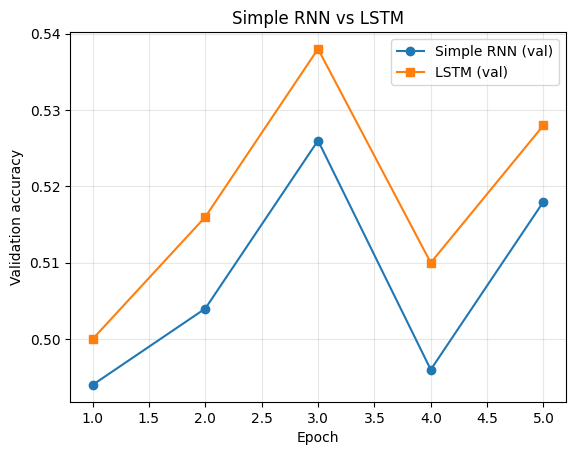

Model         Best val acc   Train time (s) 
Simple RNN    0.526          215.9          
LSTM          0.538          112.4          


In [10]:
import matplotlib.pyplot as plt
epochs = range(1, len(rnn_hist["val_acc"]) + 1)
plt.plot(epochs, rnn_hist["val_acc"], "o-", label="Simple RNN (val)")
plt.plot(epochs, lstm_hist["val_acc"], "s-", label="LSTM (val)")
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy")
plt.title("Simple RNN vs LSTM"); plt.legend(); plt.grid(True, alpha=.3)
plt.show()

print(f"{'Model':<14}{'Best val acc':<15}{'Train time (s)':<15}")
for name, hist, t in [("Simple RNN", rnn_hist, rnn_time), ("LSTM", lstm_hist, lstm_time)]:
    print(f"{name:<14}{max(hist['val_acc']):<15.3f}{t:<15.1f}")

Step 8.8 — Test the “long review” question directly (RQ3)

In [11]:
def accuracy_by_length(model, dataset, threshold=200):
    model.eval()
    groups = {"short": [0, 0], "long": [0, 0]} # [correct, total]
    with torch.no_grad():
        for ex in dataset:
            length = len(ex["text"].split())
            x = torch.tensor([encode(ex["text"])], dtype=torch.long).to(device)
            pred = model(x).argmax(1).item()
            key = "long" if length > threshold else "short"
            groups[key][1] += 1
            groups[key][0] += int(pred == ex["label"])
    for key, (c, tot) in groups.items():
        acc = c / tot if tot else 0
    print(f" {key:<6} reviews ({tot:>3}): accuracy {acc:.3f}")
print("Simple RNN:")
accuracy_by_length(rnn_model, val_sample)
print("LSTM:")
accuracy_by_length(lstm_model, val_sample)

Simple RNN:
 long   reviews (166): accuracy 0.506
LSTM:
 long   reviews (166): accuracy 0.590
